<p style="background-color:Blue; font-family:newtimeroman; color:#FFF9ED; font-size:200%; text-align:center; border-radius:20px; padding:20px;"><strong>PRCP-1025-Flight Fare Prediction ✈️ </strong></p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:black; background-color:#dfa8e4; font-size: 16px; border-width: 2px; font-weight: bold;" data-toggle="popover"><span style="font-size: 20px;">AIM : </span>

- To analyze historical flight data and identify patterns affecting ticket prices.
- To build a machine learning model that predicts flight fares accurately.
- To help travelers plan their journeys by forecasting ticket prices in advance.
- To assist airlines in understanding pricing trends and optimizing fare strategies

<a id="2"></a>
## <p style="background-color:Blue; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:center; border-radius:10px 10px;"> LIBRARIES NEEDED IN THE STUDY<p>

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

import warnings
warnings.filterwarnings("ignore")


<a id="3"></a>
## <p style="background-color:Blue; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:center; border-radius:10px 10px;"> Loading and Reading Data <p>

In [14]:
df = pd.read_excel("Flight_Fare.xlsx")
df.head()


,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:black; background-color:#dfa8e4; font-size: 16px; border-width: 2px; font-weight: bold;" data-toggle="popover">
<span style="font-size: 20px;">Data Analysis</span></a>

In [15]:
df.shape

(10683, 11)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [17]:
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

In [18]:
for col in df.columns:
    print(f"'{col}'")

'Airline'
'Date_of_Journey'
'Source'
'Destination'
'Route'
'Dep_Time'
'Arrival_Time'
'Duration'
'Total_Stops'
'Additional_Info'
'Price'


<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:black; background-color:#dfa8e4; font-size: 16px; border-width: 2px; font-weight: bold;" data-toggle="popover">
<span style="font-size: 20px;">Arrival Time SAFE</span></a>

In [19]:
# Clean column names
df.columns = df.columns.str.strip()

# Departure Time
if "Dep_Time" in df.columns:
    df["Dep_Hour"] = pd.to_datetime(df["Dep_Time"]).dt.hour
    df["Dep_Min"] = pd.to_datetime(df["Dep_Time"]).dt.minute
    df.drop("Dep_Time", axis=1, inplace=True)

# Arrival Time
if "Arrival_Time" in df.columns:
    df["Arrival_Hour"] = pd.to_datetime(df["Arrival_Time"]).dt.hour
    df["Arrival_Min"] = pd.to_datetime(df["Arrival_Time"]).dt.minute
    df.drop("Arrival_Time", axis=1, inplace=True)


<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:black; background-color:#dfa8e4; font-size: 16px; border-width: 2px; font-weight: bold;" data-toggle="popover">
<span style="font-size: 20px;">Duration (MOST IMPORTANT FIX)</span></a>

In [20]:
# Handle Duration safely
if "Duration" in df.columns:
    duration = df["Duration"].copy()

    for i in range(len(duration)):
        if len(duration[i].split()) != 2:
            if "h" in duration[i]:
                duration[i] += " 0m"
            else:
                duration[i] = "0h " + duration[i]

    df["Duration_Hours"] = duration.apply(lambda x: int(x.split()[0][:-1]))
    df["Duration_Minutes"] = duration.apply(lambda x: int(x.split()[1][:-1]))
    
    df.drop("Duration", axis=1, inplace=True)
else:
    print("Duration column already processed or not present")


<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:black; background-color:#dfa8e4; font-size: 16px; border-width: 2px; font-weight: bold;" data-toggle="popover">
<span style="font-size: 20px;">Total Stop</span></a>

In [21]:
df["Total_Stops"] = df["Total_Stops"].replace({
    "non-stop": 0,
    "1 stop": 1,
    "2 stops": 2,
    "3 stops": 3,
    "4 stops": 4
}).astype(int)


In [22]:
df.drop(
    columns=[col for col in ["Route", "Additional_Info"] if col in df.columns],
    inplace=True
)


In [23]:
le = LabelEncoder()

for col in ["Airline", "Source", "Destination"]:
    df[col] = le.fit_transform(df[col])


In [24]:
df['Journey_Day'] = pd.to_datetime(
    df['Date_of_Journey'], format="%d/%m/%Y"
).dt.day

df['Journey_Month'] = pd.to_datetime(
    df['Date_of_Journey'], format="%d/%m/%Y"
).dt.month

df.drop('Date_of_Journey', axis=1, inplace=True)


<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:black; background-color:#dfa8e4; font-size: 16px; border-width: 2px; font-weight: bold;" data-toggle="popover">
<span style="font-size: 20px;">Train-Test Split</span></a>

In [25]:
X = df.drop("Price", axis=1)
y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [26]:
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)
print("Linear Regression R2:", r2_score(y_test, lr_pred))


Linear Regression R2: 0.4381543229086623


<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:black; background-color:#dfa8e4; font-size: 16px; border-width: 2px; font-weight: bold;" data-toggle="popover">
<span style="font-size: 20px;">Model Training</span></a>

In [27]:
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("Random Forest R2:", r2_score(y_test, rf_pred))


Random Forest R2: 0.7883633626078922


In [28]:
param_grid = {
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["auto", "sqrt"]
}

rf_random = RandomizedSearchCV(
    rf,
    param_distributions=param_grid,
    n_iter=15,
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

rf_random.fit(X_train, y_train)


Fitting 5 folds for each of 15 candidates, totalling 75 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 10, ...], 'max_features': ['auto', 'sqrt'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.

In [35]:
best_rf = rf_random.best_estimator_

best_pred = best_rf.predict(X_test)
print("Tuned Random Forest R2:", r2_score(y_test, best_pred))


Tuned Random Forest R2: 0.8231707105556978


array([16635.7390248 ,  5522.80920933,  8648.21661986, ...,
        6526.49195229, 12412.84368452, 12708.19397258], shape=(2137,))

In [30]:
gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train, y_train)

gbr_pred = gbr.predict(X_test)
print("Gradient Boosting R2:", r2_score(y_test, gbr_pred))


Gradient Boosting R2: 0.7902758141878982


<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:black; background-color:#dfa8e4; font-size: 16px; border-width: 2px; font-weight: bold;" data-toggle="popover">
<span style="font-size: 20px;">Encoding Categorical variable</span></a>

In [31]:
ensemble_pred = (best_pred + gbr_pred) / 2
print("Ensemble Model R2:", r2_score(y_test, ensemble_pred))


Ensemble Model R2: 0.8307644302127958


<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:black; background-color:#dfa8e4; font-size: 16px; border-width: 2px; font-weight: bold;" data-toggle="popover">
<span style="font-size: 20px;">Model Evalution</span></a>

In [32]:
def evaluate(y_true, y_pred):
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R2:", r2_score(y_true, y_pred))

evaluate(y_test, best_pred)


MAE: 1211.749263935627
RMSE: 1952.640033073057
R2: 0.8231707105556978


<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:black; background-color:#dfa8e4; font-size: 16px; border-width: 2px; font-weight: bold;" data-toggle="popover">
<span style="font-size: 20px;">Exploratory Data Analysis</span></a>

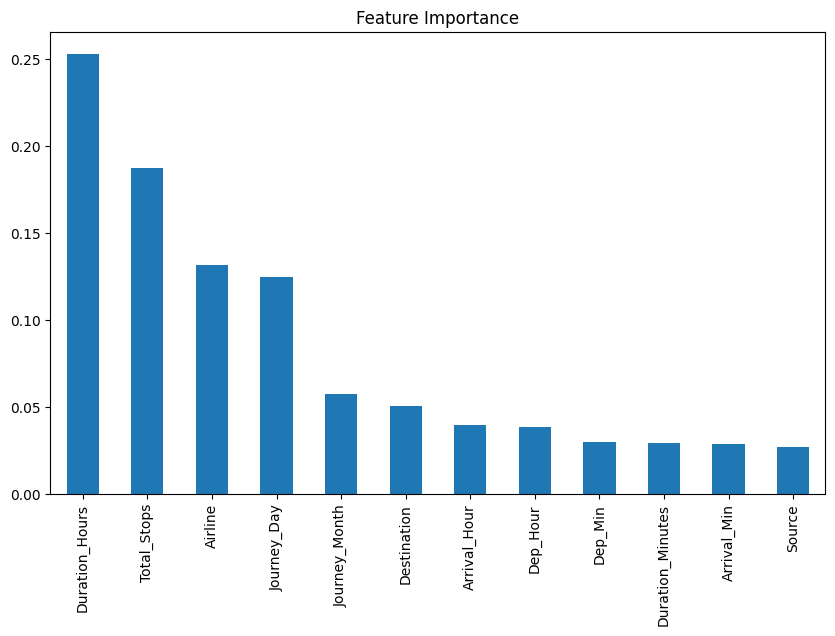

In [33]:
feature_imp = pd.Series(
    best_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feature_imp.plot(kind="bar")
plt.title("Feature Importance")
plt.show()


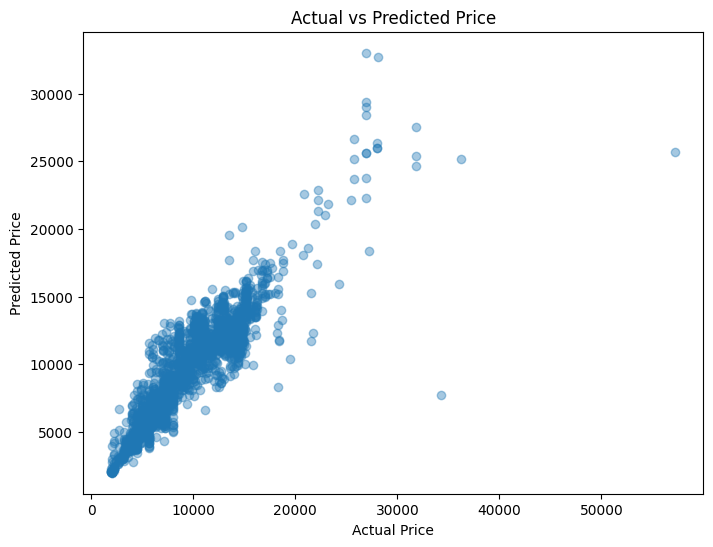

In [34]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, best_pred, alpha=0.4)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.show()


<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:black; background-color:#dfa8e4; font-size: 16px; border-width: 2px; font-weight: bold;" data-toggle="popover"><span style="font-size: 20px;">Conclusion : </span>
- Random Forest provides strong predictive performance
- Total Stops and Duration are major price drivers
- Model can help customers plan cost-effective journeys